# PNAD COVID-19 — análise de dados

**Período analisado:** setembro a novembro de 2020  
**Ferramentas:** Python, SQL e PostgreSQL/Supabase

Este notebook reúne o tratamento dos dados, as consultas feitas no banco e o modelo de clusterização usado para identificar perfis entre os registros com teste positivo.

## Principais resultados

- O percentual ponderado de pessoas que declararam teste positivo passou de **2,29% em setembro para 3,07% em novembro**.
- **Dor de cabeça (6,42%)**, **tosse (5,48%)** e **dor muscular (5,27%)** foram os sintomas mais frequentes na semana da entrevista.
- **Mulheres de 30 a 39 anos** apresentaram a maior proporção ponderada de testes positivos: **4,42%**.
- As taxas ficaram praticamente iguais entre trabalho **presencial (4,03%)** e **remoto (4,04%)**.
- **95,83%** das respostas ponderadas indicaram algum nível de restrição de contato.
- A clusterização encontrou três perfis: **adultos com poucos sintomas**, **mais velhos com comorbidades** e **jovens com mais sintomas**.

> A base reúne três rodadas mensais. Quando os meses são analisados em conjunto, a soma dos pesos representa pessoas-mês, e não indivíduos únicos. Por esse motivo, as conclusões priorizam percentuais ponderados. As análises são descritivas e não demonstram causalidade.

## 1. Preparação do ambiente

As credenciais do banco foram mantidas em um arquivo `.env`, fora do notebook. Para executar o projeto em outra máquina, basta ajustar o caminho principal abaixo.

In [10]:
import os
from io import StringIO
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
import seaborn as sns
import sklearn
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

sns.set_theme(style="white", context="notebook")

PASTA_PROJETO = Path.cwd()

PASTA_DADOS = PASTA_PROJETO / "00_dados_brutos"
PASTA_DICIONARIO = PASTA_PROJETO / "01_dicionario"
PASTA_IMAGENS = PASTA_PROJETO / "imagens"
PASTA_MODELO = PASTA_PROJETO / "modelo"

ARQUIVO_DICIONARIO = (
    PASTA_DICIONARIO
    / "Dicionario_PNAD_COVID.xlsx"
)

ARQUIVO_ENV = PASTA_PROJETO / ".env"

PASTA_IMAGENS.mkdir(parents=True, exist_ok=True)
PASTA_MODELO.mkdir(parents=True, exist_ok=True)

In [11]:
print("Pasta do projeto:", PASTA_PROJETO)
print("Pasta de imagens:", PASTA_IMAGENS)
print("Pasta do modelo:", PASTA_MODELO)

print(
    "A pasta de imagens existe?",
    PASTA_IMAGENS.exists()
)

print(
    "A pasta do modelo existe?",
    PASTA_MODELO.exists()
)

Pasta do projeto: c:\Users\LUIS\OneDrive\MEU ARQUIVOS - CURSOS\FACULDADE\FIAP\FASE 3\pnad_covid_fase3
Pasta de imagens: c:\Users\LUIS\OneDrive\MEU ARQUIVOS - CURSOS\FACULDADE\FIAP\FASE 3\pnad_covid_fase3\imagens
Pasta do modelo: c:\Users\LUIS\OneDrive\MEU ARQUIVOS - CURSOS\FACULDADE\FIAP\FASE 3\pnad_covid_fase3\modelo
A pasta de imagens existe? True
A pasta do modelo existe? True


## 2. Leitura e consolidação das bases

In [12]:
arquivos_mensais = {
    "2020-09": PASTA_DADOS / "PNAD_COVID_092020.csv",
    "2020-10": PASTA_DADOS / "PNAD_COVID_102020.csv",
    "2020-11": PASTA_DADOS / "PNAD_COVID_112020.csv",
}

bases_mensais = {
    mes: pd.read_csv(arquivo, dtype=str, low_memory=False)
    for mes, arquivo in arquivos_mensais.items()
}

resumo_bases = pd.DataFrame([
    {"mes": mes, "linhas": len(base), "colunas": base.shape[1]}
    for mes, base in bases_mensais.items()
])

resumo_bases

,mes,linhas,colunas
0,2020-09,387298,145
1,2020-10,380461,145
2,2020-11,381438,148


In [13]:
for mes, base in bases_mensais.items():
    base["MES_REFERENCIA"] = mes

dados_pnad = pd.concat(bases_mensais.values(), ignore_index=True, sort=False)

print(f"Linhas consolidadas: {len(dados_pnad):,}")
print(f"Colunas consolidadas: {dados_pnad.shape[1]}")

Linhas consolidadas: 1,149,197
Colunas consolidadas: 149


## 3. Tratamento e definição das variáveis

Foi criado o indicador `INFECTADO`, igual a 1 quando pelo menos um dos três testes investigados — swab, sangue do dedo ou sangue da veia — apresentou resultado positivo.

In [14]:
dicionario_pnad = pd.read_excel(
    ARQUIVO_DICIONARIO,
    sheet_name="dicionário pnad covid",
    header=None,
)

colunas_resultado_teste = ["B009B", "B009D", "B009F"]

dados_pnad["INFECTADO"] = (
    dados_pnad[colunas_resultado_teste]
    .eq("1")
    .any(axis=1)
    .astype("int8")
)

dados_pnad["INFECTADO"].value_counts(dropna=False)

C:\Users\LUIS\AppData\Local\Temp\ipykernel_10128\4189800662.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dados_pnad["INFECTADO"] = (


INFECTADO
0    1116275
1      32922
Name: count, dtype: int64

In [15]:
variaveis_identificacao = [
    "Ano",
    "UF",
    "V1022",  # Situação do domicílio: urbano ou rural
    "V1032",  # Peso amostral
    "MES_REFERENCIA"
]

variaveis_perfil = [
    "A002",  # Idade
    "A003",  # Sexo
    "A004",  # Cor ou raça
    "A005"   # Escolaridade
]

variaveis_sintomas = [
    "B0011",   # Febre
    "B0012",   # Tosse
    "B0013",   # Dor de garganta
    "B0014",   # Dificuldade para respirar
    "B0015",   # Dor de cabeça
    "B0016",   # Dor no peito
    "B0017",   # Náusea
    "B0018",   # Nariz entupido ou escorrendo
    "B0019",   # Fadiga
    "B00110",  # Dor nos olhos
    "B00111",  # Perda de cheiro ou sabor
    "B00112",  # Dor muscular
    "B00113"   # Diarreia
]

variaveis_saude = [
    "B008",   # Realizou algum teste
    "B009B",  # Resultado do SWAB
    "B009D",  # Resultado do sangue pelo dedo
    "B009F",  # Resultado do sangue pela veia
    "B0101",  # Diabetes
    "B0102",  # Hipertensão
    "B0103",  # Doença respiratória crônica
    "B0104",  # Doença do coração
    "B0105",  # Depressão
    "B0106"   # Câncer
]

variaveis_comportamento = [
    "B011",   # Restrição de contato
    "F002A1", # Sabão ou detergente
    "F002A2", # Álcool 70%
    "F002A3", # Máscaras
    "F002A4", # Luvas descartáveis
    "F002A5"  # Água sanitária ou desinfetante
]

variaveis_trabalho = [
    "C001",   # Trabalhou na semana
    "C002",   # Estava afastado
    "C003",   # Motivo do afastamento
    "C007",   # Posição no trabalho
    "C007C",  # Cargo ou função
    "C007D",  # Atividade da empresa
    "C008",   # Horas normalmente trabalhadas
    "C009",   # Horas efetivamente trabalhadas
    "C012",   # Trabalhou no local habitual
    "C013"    # Trabalho remoto
]

In [16]:
base_tratada = dados_pnad.copy()

for coluna in ["A002", "V1032", "C008", "C009"]:
    base_tratada[coluna] = pd.to_numeric(
        base_tratada[coluna],
        errors="coerce",
    )

validacoes_numericas = {
    "idades_invalidas": (
        ~base_tratada["A002"].between(0, 130)
        & base_tratada["A002"].notna()
    ).sum(),
    "pesos_invalidos": (
        base_tratada["V1032"].le(0)
        & base_tratada["V1032"].notna()
    ).sum(),
    "horas_habituais_invalidas": (
        ~base_tratada["C008"].between(1, 120)
        & base_tratada["C008"].notna()
    ).sum(),
    "horas_efetivas_invalidas": (
        ~base_tratada["C009"].between(0, 120)
        & base_tratada["C009"].notna()
    ).sum(),
}

pd.Series(validacoes_numericas, name="quantidade")

idades_invalidas             0
pesos_invalidos              0
horas_habituais_invalidas    0
horas_efetivas_invalidas     0
Name: quantidade, dtype: int64

### Estrutura destinada ao banco de dados

In [17]:
mapa_nomes_colunas = {
    # Identificação
    "Ano": "ano",
    "UF": "uf",
    "V1022": "situacao_domicilio",
    "V1032": "peso_amostral",
    "MES_REFERENCIA": "mes_referencia",

    # Perfil
    "A002": "idade",
    "A003": "sexo",
    "A004": "cor_raca",
    "A005": "escolaridade",

    # Sintomas
    "B0011": "sintoma_febre",
    "B0012": "sintoma_tosse",
    "B0013": "sintoma_dor_garganta",
    "B0014": "sintoma_dificuldade_respirar",
    "B0015": "sintoma_dor_cabeca",
    "B0016": "sintoma_dor_peito",
    "B0017": "sintoma_nausea",
    "B0018": "sintoma_nariz_entupido",
    "B0019": "sintoma_fadiga",
    "B00110": "sintoma_dor_olhos",
    "B00111": "sintoma_perda_olfato_paladar",
    "B00112": "sintoma_dor_muscular",
    "B00113": "sintoma_diarreia",

    # Testes
    "B008": "realizou_teste",
    "B009B": "resultado_swab",
    "B009D": "resultado_sangue_dedo",
    "B009F": "resultado_sangue_veia",

    # Condições de saúde
    "B0101": "possui_diabetes",
    "B0102": "possui_hipertensao",
    "B0103": "possui_doenca_respiratoria",
    "B0104": "possui_doenca_coracao",
    "B0105": "possui_depressao",
    "B0106": "possui_cancer",

    # Comportamento
    "B011": "nivel_restricao_contato",
    "F002A1": "domicilio_possui_sabao",
    "F002A2": "domicilio_possui_alcool_70",
    "F002A3": "domicilio_possui_mascaras",
    "F002A4": "domicilio_possui_luvas",
    "F002A5": "domicilio_possui_desinfetante",

    # Trabalho
    "C001": "trabalhou_na_semana",
    "C002": "afastado_do_trabalho",
    "C003": "motivo_afastamento",
    "C007": "posicao_ocupacao",
    "C007C": "cargo_funcao",
    "C007D": "atividade_empresa",
    "C008": "horas_trabalho_habitual",
    "C009": "horas_trabalho_efetiva",
    "C012": "trabalhou_local_habitual",
    "C013": "trabalho_remoto",

    # Variável derivada
    "INFECTADO": "infectado"
}

In [18]:
colunas_banco = list(mapa_nomes_colunas)
base_banco = base_tratada[colunas_banco].rename(columns=mapa_nomes_colunas).copy()
base_banco.insert(0, "id_registro", range(1, len(base_banco) + 1))

In [19]:
print(f"Registros preparados: {len(base_banco):,}")
print(f"Colunas selecionadas: {base_banco.shape[1]}")
base_banco.head()

Registros preparados: 1,149,197
Colunas selecionadas: 50


,id_registro,ano,uf,situacao_domicilio,peso_amostral,mes_referencia,idade,sexo,cor_raca,escolaridade,...,afastado_do_trabalho,motivo_afastamento,posicao_ocupacao,cargo_funcao,atividade_empresa,horas_trabalho_habitual,horas_trabalho_efetiva,trabalhou_local_habitual,trabalho_remoto,infectado
0,1,2020,11,1,164.209361,2020-09,36,1,4,5,...,NaN,NaN,04,35,06,48.0,48.0,1,NaN,0
1,2,2020,11,1,166.944610,2020-09,30,2,4,7,...,NaN,NaN,07,27,20,36.0,36.0,1,NaN,0
2,3,2020,11,1,171.887754,2020-09,13,1,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,4,2020,11,1,171.887754,2020-09,11,1,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,5,2020,11,1,127.536682,2020-09,57,2,1,2,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## 4. PostgreSQL/Supabase

A tabela foi criada no PostgreSQL e recebeu **1.149.197 registros** por meio do `COPY` em lotes de 50 mil linhas. Antes da carga completa, uma tabela temporária foi utilizada para validar 1.000 registros. A carga completa fica desativada por padrão para impedir duplicidade durante uma execução acidental do notebook.

In [20]:
load_dotenv(dotenv_path=ARQUIVO_ENV, override=True)

variaveis_conexao = [
    "SUPABASE_DB_HOST",
    "SUPABASE_DB_PORT",
    "SUPABASE_DB_NAME",
    "SUPABASE_DB_USER",
    "SUPABASE_DB_PASSWORD",
]

variaveis_ausentes = [
    variavel for variavel in variaveis_conexao
    if not os.getenv(variavel)
]

if variaveis_ausentes:
    raise ValueError(
        "Variáveis ausentes no .env: " + ", ".join(variaveis_ausentes)
    )

conexao_config = {
    "host": os.getenv("SUPABASE_DB_HOST"),
    "port": os.getenv("SUPABASE_DB_PORT"),
    "dbname": os.getenv("SUPABASE_DB_NAME"),
    "user": os.getenv("SUPABASE_DB_USER"),
    "password": os.getenv("SUPABASE_DB_PASSWORD"),
    "connect_timeout": 15,
}

url_sqlalchemy = URL.create(
    drivername="postgresql+psycopg",
    username=conexao_config["user"],
    password=conexao_config["password"],
    host=conexao_config["host"],
    port=int(conexao_config["port"]),
    database=conexao_config["dbname"],
)

engine = create_engine(
    url_sqlalchemy,
    pool_pre_ping=True,
    pool_recycle=300,
    connect_args={"connect_timeout": 15},
)

with engine.connect() as conexao:
    banco, usuario = conexao.execute(
        text("SELECT current_database(), current_user")
    ).one()

print(f"Conexão realizada — banco: {banco} | usuário: {usuario}")

Conexão realizada — banco: postgres | usuário: postgres


### Carga em lote — execução protegida

Para refazer a carga, a tabela deve existir e estar vazia. Altere `EXECUTAR_CARGA` para `True` somente após conferir essas duas condições.

In [21]:
EXECUTAR_CARGA = False
TAMANHO_LOTE = 50_000

if EXECUTAR_CARGA:
    with engine.connect() as conexao:
        quantidade_atual = conexao.execute(
            text("SELECT COUNT(*) FROM public.pnad_covid")
        ).scalar_one()

    if quantidade_atual != 0:
        raise ValueError(
            f"Carga interrompida: a tabela já possui {quantidade_atual:,} registros."
        )

    colunas_banco = list(base_banco.columns)
    colunas_inteiras = [
        "id_registro", "ano", "idade",
        "horas_trabalho_habitual", "horas_trabalho_efetiva", "infectado",
    ]
    nomes_colunas = ", ".join(colunas_banco)
    comando_copy = f"""
        COPY public.pnad_covid ({nomes_colunas})
        FROM STDIN WITH (FORMAT CSV, NULL '\\N');
    """

    inicio_carga = perf_counter()

    with psycopg.connect(**conexao_config) as conexao:
        with conexao.cursor() as cursor:
            cursor.execute("SET statement_timeout TO 0;")

            with cursor.copy(comando_copy) as copy:
                for inicio in range(0, len(base_banco), TAMANHO_LOTE):
                    fim = min(inicio + TAMANHO_LOTE, len(base_banco))
                    lote = base_banco.iloc[inicio:fim].copy()

                    for coluna in colunas_inteiras:
                        lote[coluna] = (
                            pd.to_numeric(lote[coluna], errors="coerce")
                            .astype("Int64")
                            .astype("string")
                        )

                    buffer_lote = StringIO()
                    lote.to_csv(
                        buffer_lote,
                        index=False,
                        header=False,
                        na_rep="\\N",
                    )
                    copy.write(buffer_lote.getvalue())

    print(f"Carga concluída em {(perf_counter() - inicio_carga) / 60:.2f} minutos.")
else:
    print("Carga desativada: os dados já estão armazenados no banco.")

Carga desativada: os dados já estão armazenados no banco.


In [22]:
sql_validacao_final = text("""
    SELECT
        COUNT(*) AS quantidade_registros,
        MIN(id_registro) AS primeiro_id,
        MAX(id_registro) AS ultimo_id,
        SUM(infectado) AS infectados,
        ROUND(100.0 * SUM(infectado) / COUNT(*), 2) AS percentual_infectados
    FROM public.pnad_covid;
""")

with engine.connect() as conexao:
    resultado_final = conexao.execute(sql_validacao_final).mappings().one()

print(f"Quantidade de registros: {resultado_final['quantidade_registros']:,}")
print(f"Primeiro ID: {resultado_final['primeiro_id']:,}")
print(f"Último ID: {resultado_final['ultimo_id']:,}")
print(f"Infectados: {resultado_final['infectados']:,}")
print(f"Percentual: {resultado_final['percentual_infectados']}%")

Quantidade de registros: 1,149,197
Primeiro ID: 1
Último ID: 1,149,197
Infectados: 32,922
Percentual: 2.86%


## 5. Análises

Todas as análises abaixo são executadas no PostgreSQL. O peso amostral foi utilizado para aproximar os percentuais da população representada pela pesquisa.

### 5.1 Evolução mensal dos testes positivos

In [23]:
sql_evolucao_infectados = text("""
    SELECT
        mes_referencia,

        COUNT(*) AS total_entrevistados,

        SUM(infectado) AS infectados_amostra,

        ROUND(
            (
                100.0 * SUM(infectado)
                / COUNT(*)
            )::NUMERIC,
            2
        ) AS percentual_amostra,

        ROUND(
            SUM(peso_amostral)::NUMERIC,
            0
        ) AS populacao_estimada,

        ROUND(
            SUM(
                CASE
                    WHEN infectado = 1
                    THEN peso_amostral
                    ELSE 0
                END
            )::NUMERIC,
            0
        ) AS infectados_estimados,

        ROUND(
            (
                100.0
                * SUM(
                    CASE
                        WHEN infectado = 1
                        THEN peso_amostral
                        ELSE 0
                    END
                )
                / SUM(peso_amostral)
            )::NUMERIC,
            2
        ) AS percentual_ponderado

    FROM public.pnad_covid

    GROUP BY
        mes_referencia

    ORDER BY
        mes_referencia;
""")

In [24]:
df_evolucao_infectados = pd.read_sql(
    sql_evolucao_infectados,
    engine
)

df_evolucao_infectados

,mes_referencia,total_entrevistados,infectados_amostra,percentual_amostra,populacao_estimada,infectados_estimados,percentual_ponderado
0,2020-09,387298,9519,2.46,211392451.0,4847476.0,2.29
1,2020-10,380461,10951,2.88,211522549.0,5743799.0,2.72
2,2020-11,381438,12452,3.26,211652369.0,6497553.0,3.07


In [25]:
colunas_grafico = [
    "percentual_amostra",
    "populacao_estimada",
    "infectados_estimados",
    "percentual_ponderado"
]

for coluna in colunas_grafico:
    df_evolucao_infectados[coluna] = pd.to_numeric(
        df_evolucao_infectados[coluna],
        errors="coerce"
    )

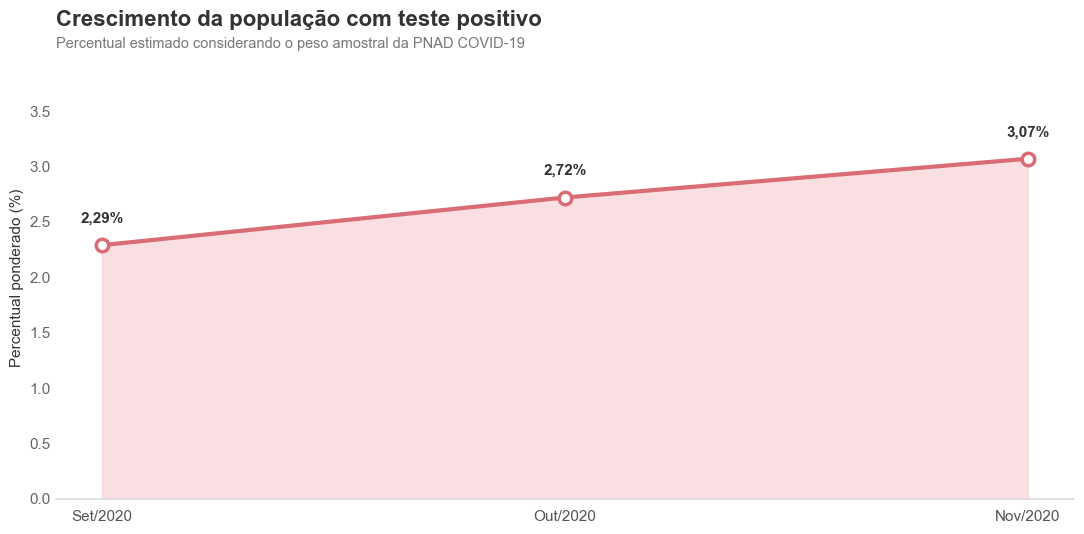

In [26]:
sns.set_theme(
    style="white",
    context="notebook"
)

# Ordena os meses antes do gráfico
df_grafico = (
    df_evolucao_infectados
    .sort_values("mes_referencia")
    .copy()
)

x = np.arange(len(df_grafico))

y = (
    df_grafico["percentual_ponderado"]
    .astype(float)
    .to_numpy()
)

rotulos_meses = {
    "2020-09": "Set/2020",
    "2020-10": "Out/2020",
    "2020-11": "Nov/2020"
}

meses = (
    df_grafico["mes_referencia"]
    .map(rotulos_meses)
    .fillna(df_grafico["mes_referencia"])
    .tolist()
)

# Paleta em vermelho pastel
cor_linha = "#D96C75"
cor_area = "#F3B5BA"
cor_texto = "#333333"

fig, ax = plt.subplots(
    figsize=(11, 5.5),
    facecolor="white"
)

# Área sob a linha
ax.fill_between(
    x,
    y,
    0,
    color=cor_area,
    alpha=0.42,
    zorder=1
)

# Linha principal
ax.plot(
    x,
    y,
    color=cor_linha,
    linewidth=3,
    marker="o",
    markersize=9,
    markerfacecolor="white",
    markeredgecolor=cor_linha,
    markeredgewidth=2.5,
    zorder=2
)

# Rótulos dos pontos
for posicao, percentual in zip(x, y):
    ax.annotate(
        f"{percentual:.2f}%".replace(".", ","),
        xy=(posicao, percentual),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=cor_texto
    )

ax.set_title(
    "Crescimento da população com teste positivo",
    fontsize=16,
    fontweight="bold",
    color=cor_texto,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.02,
    "Percentual estimado considerando o peso amostral da PNAD COVID-19",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xticks(x)
ax.set_xticklabels(
    meses,
    fontsize=11
)

ax.set_xlabel("")
ax.set_ylabel(
    "Percentual ponderado (%)",
    fontsize=11,
    color=cor_texto
)

# Começa em zero para a área representar corretamente a magnitude
ax.set_ylim(
    0,
    max(y) * 1.30
)

# Remove linhas de grade e bordas desnecessárias
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#DDDDDD")

ax.tick_params(
    axis="y",
    length=0,
    colors="#666666"
)

ax.tick_params(
    axis="x",
    length=0,
    colors="#555555",
    pad=8
)

plt.tight_layout()

fig.savefig(
    PASTA_IMAGENS / "evolucao_testes_positivos.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

**Resultado.** A proporção ponderada de pessoas que declararam pelo menos um teste positivo passou de **2,29% em setembro para 3,07% em novembro de 2020**, crescimento relativo aproximado de **34%**. Esses valores não representam novos casos mensais, pois o teste pode ter ocorrido antes da entrevista.

### 5.2 Quais foram os principais sintomas?

In [27]:
sql_principais_sintomas = text("""
    WITH infectados AS (
        SELECT
            peso_amostral,
            sintoma_febre,
            sintoma_tosse,
            sintoma_dor_garganta,
            sintoma_dificuldade_respirar,
            sintoma_dor_cabeca,
            sintoma_dor_peito,
            sintoma_nausea,
            sintoma_nariz_entupido,
            sintoma_fadiga,
            sintoma_dor_olhos,
            sintoma_perda_olfato_paladar,
            sintoma_dor_muscular,
            sintoma_diarreia
        FROM public.pnad_covid
        WHERE infectado = 1
    ),

    sintomas_unificados AS (
        SELECT
            peso_amostral,
            sintomas.nome_sintoma,
            sintomas.codigo_resposta

        FROM infectados

        CROSS JOIN LATERAL (
            VALUES
                ('Febre', sintoma_febre),
                ('Tosse', sintoma_tosse),
                ('Dor de garganta', sintoma_dor_garganta),
                ('Dificuldade para respirar', sintoma_dificuldade_respirar),
                ('Dor de cabeça', sintoma_dor_cabeca),
                ('Dor no peito', sintoma_dor_peito),
                ('Náusea', sintoma_nausea),
                ('Nariz entupido ou escorrendo', sintoma_nariz_entupido),
                ('Fadiga', sintoma_fadiga),
                ('Dor nos olhos', sintoma_dor_olhos),
                ('Perda de olfato ou paladar', sintoma_perda_olfato_paladar),
                ('Dor muscular', sintoma_dor_muscular),
                ('Diarreia', sintoma_diarreia)
        ) AS sintomas (
            nome_sintoma,
            codigo_resposta
        )
    )

    SELECT
        nome_sintoma,

        COUNT(*) FILTER (
            WHERE codigo_resposta = '1'
        ) AS entrevistados_com_sintoma,

        ROUND(
            SUM(
                CASE
                    WHEN codigo_resposta = '1'
                    THEN peso_amostral
                    ELSE 0
                END
            )::NUMERIC,
            0
        ) AS pessoas_estimadas,

        ROUND(
            (
                100.0
                * SUM(
                    CASE
                        WHEN codigo_resposta = '1'
                        THEN peso_amostral
                        ELSE 0
                    END
                )
                / SUM(peso_amostral)
            )::NUMERIC,
            2
        ) AS percentual_ponderado

    FROM sintomas_unificados

    GROUP BY
        nome_sintoma

    ORDER BY
        percentual_ponderado DESC;
""")

In [28]:
df_principais_sintomas = pd.read_sql(
    sql_principais_sintomas,
    engine
)

df_principais_sintomas

,nome_sintoma,entrevistados_com_sintoma,pessoas_estimadas,percentual_ponderado
0,Dor de cabeça,2201,1096909.0,6.42
1,Tosse,1872,936341.0,5.48
2,Dor muscular,1797,900776.0,5.27
3,Perda de olfato ou paladar,1652,854474.0,5.00
4,Febre,1745,850424.0,4.98
5,Fadiga,1633,802306.0,4.69
6,Dor de garganta,1576,761315.0,4.46
7,Nariz entupido ou escorrendo,1446,746348.0,4.37
8,Dificuldade para respirar,1055,544228.0,3.18
9,Náusea,852,399891.0,2.34


In [29]:
df_principais_sintomas[
    "pessoas_estimadas"
] = pd.to_numeric(
    df_principais_sintomas["pessoas_estimadas"],
    errors="coerce"
)

df_principais_sintomas[
    "percentual_ponderado"
] = pd.to_numeric(
    df_principais_sintomas["percentual_ponderado"],
    errors="coerce"
)

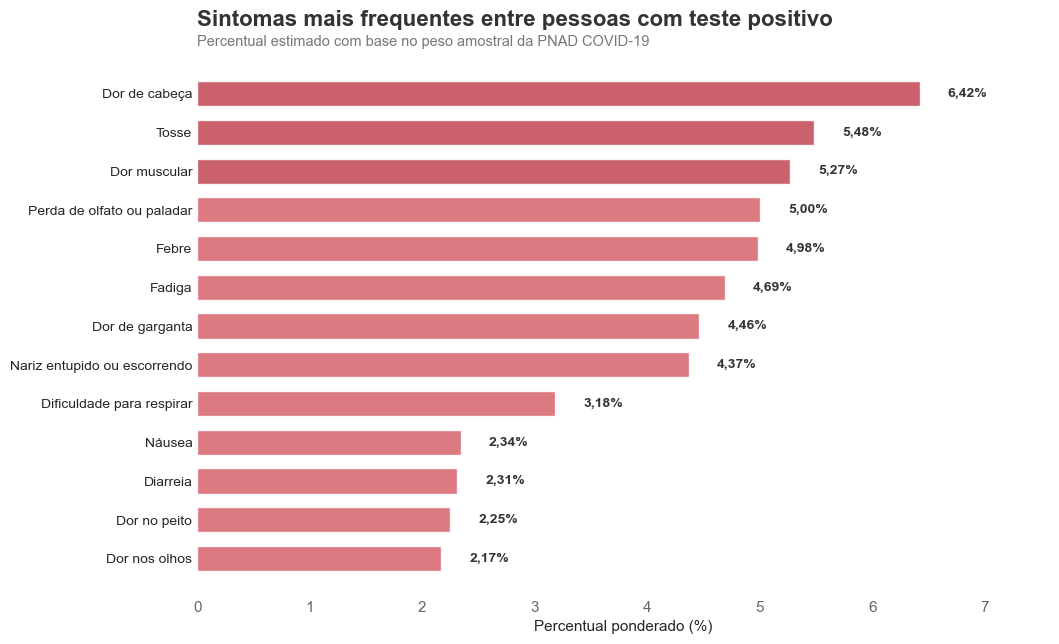

In [82]:
sns.set_theme(
    style="white",
    context="notebook"
)

df_grafico_sintomas = (
    df_principais_sintomas
    .sort_values(
        "percentual_ponderado",
        ascending=True
    )
    .copy()
)

cor_barra = "#D96C75"
cor_destaque = "#C6505D"
cor_texto = "#333333"

cores = [
    cor_destaque
    if posicao >= len(df_grafico_sintomas) - 3
    else cor_barra
    for posicao in range(len(df_grafico_sintomas))
]

fig, ax = plt.subplots(
    figsize=(11, 7),
    facecolor="white"
)

barras = ax.barh(
    df_grafico_sintomas["nome_sintoma"],
    df_grafico_sintomas["percentual_ponderado"],
    color=cores,
    alpha=0.90,
    height=0.65
)

for barra, percentual in zip(
    barras,
    df_grafico_sintomas["percentual_ponderado"]
):
    ax.text(
        percentual + 0.25,
        barra.get_y() + barra.get_height() / 2,
        f"{percentual:.2f}%".replace(".", ","),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=cor_texto
    )

ax.set_title(
    "Sintomas mais frequentes entre pessoas com teste positivo",
    fontsize=16,
    fontweight="bold",
    color=cor_texto,
    loc="left",
    pad=22
)

ax.text(
    0,
    1.02,
    "Percentual estimado com base no peso amostral da PNAD COVID-19",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel(
    "Percentual ponderado (%)",
    fontsize=11
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    df_grafico_sintomas[
        "percentual_ponderado"
    ].max() * 1.18
)

ax.grid(False)

for borda in [
    "top",
    "right",
    "left",
    "bottom"
]:
    ax.spines[borda].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
    labelsize=10
)

ax.tick_params(
    axis="x",
    length=0,
    colors="#666666"
)

fig.savefig(
    PASTA_IMAGENS / "principais_sintomas.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

**Resultado.** Dor de cabeça (**6,42%**), tosse (**5,48%**) e dor muscular (**5,27%**) foram os sintomas semanais mais frequentes entre pessoas que declararam pelo menos um teste positivo.

**Limitação.** Os sintomas se referem à semana da entrevista, enquanto o teste positivo pode ter ocorrido anteriormente. A pesquisa não permite atribuir causalidade entre o teste e cada sintoma.

### 5.3 Qual foi o público com maior percentual de testes positivos?

In [31]:
sql_perfil_idade_sexo = text("""
    WITH perfil AS (
        SELECT
            CASE
                WHEN idade BETWEEN 0 AND 11
                    THEN '0 a 11 anos'
                WHEN idade BETWEEN 12 AND 17
                    THEN '12 a 17 anos'
                WHEN idade BETWEEN 18 AND 29
                    THEN '18 a 29 anos'
                WHEN idade BETWEEN 30 AND 39
                    THEN '30 a 39 anos'
                WHEN idade BETWEEN 40 AND 49
                    THEN '40 a 49 anos'
                WHEN idade BETWEEN 50 AND 59
                    THEN '50 a 59 anos'
                WHEN idade BETWEEN 60 AND 69
                    THEN '60 a 69 anos'
                WHEN idade BETWEEN 70 AND 79
                    THEN '70 a 79 anos'
                WHEN idade >= 80
                    THEN '80 anos ou mais'
            END AS faixa_etaria,

            CASE
                WHEN sexo = '1' THEN 'Homem'
                WHEN sexo = '2' THEN 'Mulher'
                ELSE 'Não informado'
            END AS sexo,

            peso_amostral,
            infectado

        FROM public.pnad_covid
    )

    SELECT
        faixa_etaria,
        sexo,

        COUNT(*) AS total_entrevistados,

        SUM(infectado) AS infectados_amostra,

        ROUND(
            SUM(peso_amostral)::NUMERIC,
            0
        ) AS populacao_estimada,

        ROUND(
            SUM(
                CASE
                    WHEN infectado = 1
                    THEN peso_amostral
                    ELSE 0
                END
            )::NUMERIC,
            0
        ) AS infectados_estimados,

        ROUND(
            (
                100.0
                * SUM(
                    CASE
                        WHEN infectado = 1
                        THEN peso_amostral
                        ELSE 0
                    END
                )
                / SUM(peso_amostral)
            )::NUMERIC,
            2
        ) AS percentual_positivo_grupo

    FROM perfil

    WHERE faixa_etaria IS NOT NULL

    GROUP BY
        faixa_etaria,
        sexo

    ORDER BY
        faixa_etaria,
        sexo;
""")

In [32]:
df_perfil_idade_sexo = pd.read_sql(
    sql_perfil_idade_sexo,
    engine
)

df_perfil_idade_sexo

,faixa_etaria,sexo,total_entrevistados,infectados_amostra,populacao_estimada,infectados_estimados,percentual_positivo_grupo
0,0 a 11 anos,Homem,85448,698,53667378.0,443311.0,0.83
1,0 a 11 anos,Mulher,82188,744,51340248.0,467025.0,0.91
2,12 a 17 anos,Homem,53092,621,28203573.0,290925.0,1.03
3,12 a 17 anos,Mulher,50620,720,27115197.0,364783.0,1.35
4,18 a 29 anos,Homem,95224,2650,60870471.0,1573179.0,2.58
5,18 a 29 anos,Mulher,95893,3280,59863983.0,1876685.0,3.13
6,30 a 39 anos,Homem,80184,3276,50502975.0,1952293.0,3.87
7,30 a 39 anos,Mulher,88603,3989,51882185.0,2294752.0,4.42
8,40 a 49 anos,Homem,76780,3020,42580675.0,1614961.0,3.79
9,40 a 49 anos,Mulher,87570,3847,45439926.0,1875742.0,4.13


In [33]:
colunas_numericas_perfil = [
    "populacao_estimada",
    "infectados_estimados",
    "percentual_positivo_grupo"
]

for coluna in colunas_numericas_perfil:
    df_perfil_idade_sexo[coluna] = pd.to_numeric(
        df_perfil_idade_sexo[coluna],
        errors="coerce"
    )

In [34]:
ordem_faixas = [
    "0 a 11 anos",
    "12 a 17 anos",
    "18 a 29 anos",
    "30 a 39 anos",
    "40 a 49 anos",
    "50 a 59 anos",
    "60 a 69 anos",
    "70 a 79 anos",
    "80 anos ou mais"
]

tabela_calor = (
    df_perfil_idade_sexo
    .pivot(
        index="faixa_etaria",
        columns="sexo",
        values="percentual_positivo_grupo"
    )
    .reindex(ordem_faixas)
)

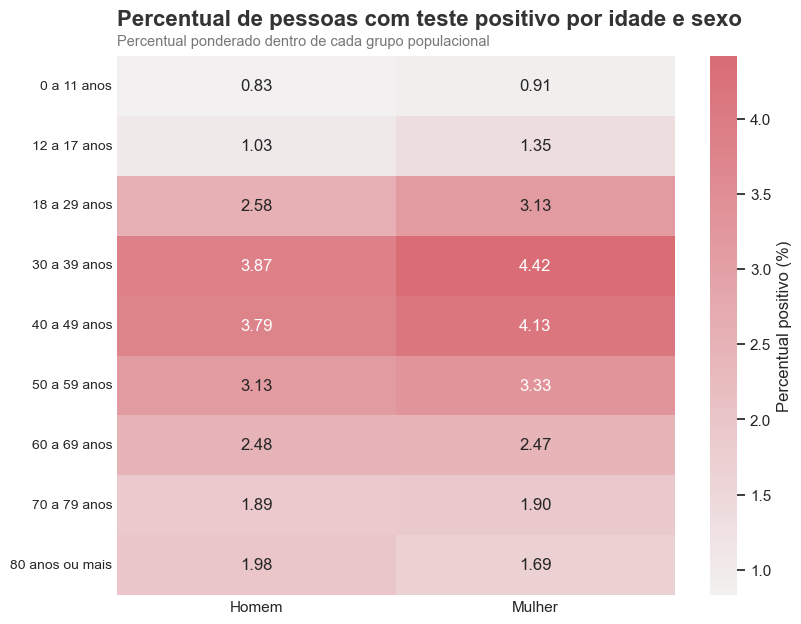

In [83]:
sns.set_theme(
    style="white",
    context="notebook"
)

mapa_vermelho_pastel = sns.light_palette(
    "#D96C75",
    as_cmap=True
)

fig, ax = plt.subplots(
    figsize=(9, 7),
    facecolor="white"
)

sns.heatmap(
    tabela_calor,
    annot=True,
    fmt=".2f",
    cmap=mapa_vermelho_pastel,
    linewidths=0,
    cbar_kws={
        "label": "Percentual positivo (%)"
    },
    ax=ax
)

ax.set_title(
    "Percentual de pessoas com teste positivo por idade e sexo",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    loc="left",
    pad=22
)

ax.text(
    0,
    1.02,
    "Percentual ponderado dentro de cada grupo populacional",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=11
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

ax.tick_params(
    axis="both",
    length=0
)

fig.savefig(
    PASTA_IMAGENS / "perfil_idade_sexo.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

**Resultado.** Mulheres de **30 a 39 anos** apresentaram o maior percentual ponderado de testes positivos, com **4,42%**, seguidas pelas mulheres de 40 a 49 anos, com **4,13%**. As mulheres superaram os homens em quase todas as faixas entre 0 e 59 anos; as exceções ocorreram entre 60 e 69 anos e a partir de 80 anos.

### 5.4 Como o trabalho presencial se relacionou com os testes positivos?

Foram comparados apenas entrevistados cuja modalidade pôde ser classificada. Considerou-se remoto quem declarou trabalho remoto e presencial quem trabalhou no local habitual ou fora dele sem trabalho remoto.

In [36]:
sql_impacto_trabalho_presencial = text("""
    WITH trabalhadores AS (
        SELECT
            peso_amostral,
            infectado,

            CASE
                WHEN trabalhou_na_semana = '1'
                     AND trabalhou_local_habitual = '2'
                     AND trabalho_remoto = '1'
                    THEN 'Remoto'

                WHEN trabalhou_na_semana = '1'
                     AND (
                         trabalhou_local_habitual = '1'
                         OR (
                             trabalhou_local_habitual = '2'
                             AND trabalho_remoto = '2'
                         )
                     )
                    THEN 'Presencial'

                WHEN trabalhou_na_semana = '1'
                    THEN 'Indeterminado'

                ELSE 'Fora da análise'
            END AS modalidade_trabalho

        FROM public.pnad_covid
    )

    SELECT
        modalidade_trabalho,

        COUNT(*) AS entrevistados,

        SUM(infectado) AS infectados_amostra,

        ROUND(
            (
                100.0 * SUM(infectado)
                / COUNT(*)
            )::NUMERIC,
            2
        ) AS percentual_amostra,

        ROUND(
            SUM(peso_amostral)::NUMERIC,
            0
        ) AS populacao_estimada,

        ROUND(
            SUM(
                CASE
                    WHEN infectado = 1
                    THEN peso_amostral
                    ELSE 0
                END
            )::NUMERIC,
            0
        ) AS infectados_estimados,

        ROUND(
            (
                100.0
                * SUM(
                    CASE
                        WHEN infectado = 1
                        THEN peso_amostral
                        ELSE 0
                    END
                )
                / NULLIF(SUM(peso_amostral), 0)
            )::NUMERIC,
            2
        ) AS percentual_positivo_ponderado

    FROM trabalhadores

    WHERE modalidade_trabalho IN (
        'Presencial',
        'Remoto'
    )

    GROUP BY
        modalidade_trabalho

    ORDER BY
        percentual_positivo_ponderado DESC;
""")

In [37]:
df_impacto_trabalho = pd.read_sql(
    sql_impacto_trabalho_presencial,
    engine
)

colunas_numericas = [
    "populacao_estimada",
    "infectados_estimados",
    "percentual_positivo_ponderado"
]

for coluna in colunas_numericas:
    df_impacto_trabalho[coluna] = pd.to_numeric(
        df_impacto_trabalho[coluna],
        errors="coerce"
    )

print(
    df_impacto_trabalho.to_string(
        index=False
    )
)

modalidade_trabalho  entrevistados  infectados_amostra  percentual_amostra  populacao_estimada  infectados_estimados  percentual_positivo_ponderado
             Remoto          34021                1482                4.36          22999470.0              929732.0                           4.04
         Presencial         375079               15705                4.19         214239989.0             8626911.0                           4.03


In [38]:
taxas = (
    df_impacto_trabalho
    .set_index("modalidade_trabalho")
    ["percentual_positivo_ponderado"]
)

taxa_presencial = taxas["Presencial"]
taxa_remoto = taxas["Remoto"]

diferenca_pp = (
    taxa_presencial
    - taxa_remoto
)

diferenca_relativa = (
    (taxa_presencial / taxa_remoto) - 1
) * 100

razao_taxas = (
    taxa_presencial
    / taxa_remoto
)

print(
    f"Taxa presencial: "
    f"{taxa_presencial:.2f}%"
)

print(
    f"Taxa remota: "
    f"{taxa_remoto:.2f}%"
)

print(
    f"Diferença: "
    f"{diferenca_pp:.2f} ponto(s) percentual(is)"
)

print(
    f"Diferença relativa: "
    f"{diferenca_relativa:.2f}%"
)

print(
    f"Razão entre as taxas: "
    f"{razao_taxas:.2f} vez(es)"
)

Taxa presencial: 4.03%
Taxa remota: 4.04%
Diferença: -0.01 ponto(s) percentual(is)
Diferença relativa: -0.25%
Razão entre as taxas: 1.00 vez(es)


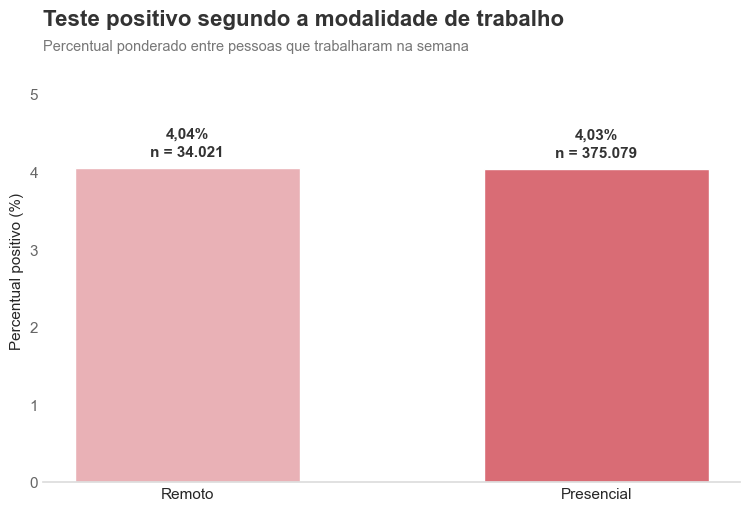

In [84]:
sns.set_theme(
    style="white",
    context="notebook"
)

df_grafico_trabalho = (
    df_impacto_trabalho
    .sort_values(
        "percentual_positivo_ponderado",
        ascending=False
    )
    .copy()
)

cores = {
    "Presencial": "#D96C75",
    "Remoto": "#E9B1B6"
}

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    facecolor="white"
)

barras = ax.bar(
    df_grafico_trabalho["modalidade_trabalho"],
    df_grafico_trabalho[
        "percentual_positivo_ponderado"
    ],
    color=[
        cores[modalidade]
        for modalidade
        in df_grafico_trabalho["modalidade_trabalho"]
    ],
    width=0.55
)

for barra, (_, linha) in zip(
    barras,
    df_grafico_trabalho.iterrows()
):
    percentual = linha[
        "percentual_positivo_ponderado"
    ]

    entrevistados = int(
        linha["entrevistados"]
    )

    percentual_formatado = (
        f"{percentual:.2f}%"
        .replace(".", ",")
    )

    entrevistados_formatado = (
        f"{entrevistados:,}"
        .replace(",", ".")
    )

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.12,
        (
            f"{percentual_formatado}\n"
            f"n = {entrevistados_formatado}"
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#333333",
        linespacing=1.4
    )

ax.set_title(
    "Teste positivo segundo a modalidade de trabalho",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.02,
    "Percentual ponderado entre pessoas que trabalharam na semana",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Percentual positivo (%)",
    fontsize=11
)

ax.set_ylim(
    0,
    df_grafico_trabalho[
        "percentual_positivo_ponderado"
    ].max() * 1.35
)

ax.grid(False)

for borda in [
    "top",
    "right",
    "left"
]:
    ax.spines[borda].set_visible(False)

ax.spines["bottom"].set_color("#DDDDDD")

ax.tick_params(
    axis="x",
    length=0,
    labelsize=11
)

ax.tick_params(
    axis="y",
    length=0,
    colors="#666666"
)

fig.savefig(
    PASTA_IMAGENS / "trabalho_presencial_remoto.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

**Resultado.** Apesar da maior quantidade absoluta de positivos no grupo presencial, ele também possuía uma amostra aproximadamente 11 vezes maior. Após considerar os denominadores e o peso amostral, as taxas foram praticamente iguais: **4,03% no presencial** e **4,04% no remoto**. Portanto, não foi observada diferença proporcional relevante entre as modalidades.

Essa comparação é descritiva. Ocupação, idade, região, renda e acesso à testagem podem influenciar o resultado.

### 5.5 Quais foram as características do comportamento da população?

O comportamento foi observado em dois eixos complementares: nível declarado de restrição de contato e disponibilidade de itens preventivos no domicílio. A posse de um item não comprova sua utilização.

In [40]:
sql_comportamento_restricao = text("""
    WITH comportamento AS (
        SELECT
            CASE
                WHEN nivel_restricao_contato = '1'
                    THEN 'Não fez restrição'

                WHEN nivel_restricao_contato = '2'
                    THEN 'Reduziu o contato, mas continuou saindo'

                WHEN nivel_restricao_contato = '3'
                    THEN 'Ficou em casa e saiu por necessidade'

                WHEN nivel_restricao_contato = '4'
                    THEN 'Ficou rigorosamente isolado'

                ELSE NULL
            END AS comportamento,

            peso_amostral

        FROM public.pnad_covid
    )

    SELECT
        comportamento,

        COUNT(*) AS entrevistados,

        ROUND(
            (
                100.0 * COUNT(*)
                / SUM(COUNT(*)) OVER ()
            )::NUMERIC,
            2
        ) AS percentual_amostra,

        ROUND(
            SUM(peso_amostral)::NUMERIC,
            0
        ) AS estimativa_ponderada,

        ROUND(
            (
                100.0 * SUM(peso_amostral)
                / SUM(SUM(peso_amostral)) OVER ()
            )::NUMERIC,
            2
        ) AS percentual_ponderado

    FROM comportamento

    WHERE comportamento IS NOT NULL

    GROUP BY
        comportamento

    ORDER BY
        percentual_ponderado DESC;
""")

In [41]:
df_comportamento_restricao = pd.read_sql(
    sql_comportamento_restricao,
    engine
)

df_comportamento_restricao[
    "percentual_ponderado"
] = pd.to_numeric(
    df_comportamento_restricao[
        "percentual_ponderado"
    ],
    errors="coerce"
)

print(
    df_comportamento_restricao.to_string(
        index=False
    )
)

                          comportamento  entrevistados  percentual_amostra  estimativa_ponderada  percentual_ponderado
Reduziu o contato, mas continuou saindo         484513               42.34           275778900.0                 43.66
   Ficou em casa e saiu por necessidade         458950               40.11           245262478.0                 38.83
            Ficou rigorosamente isolado         154593               13.51            84280165.0                 13.34
                      Não fez restrição          46194                4.04            26345061.0                  4.17


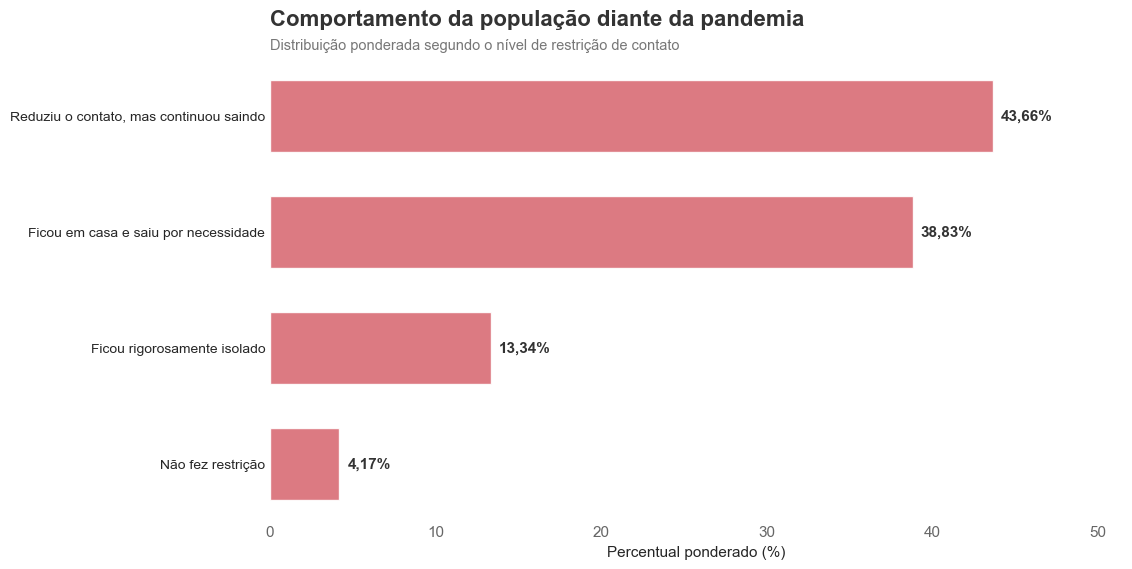

In [85]:
sns.set_theme(
    style="white",
    context="notebook"
)

df_grafico_restricao = (
    df_comportamento_restricao
    .sort_values(
        "percentual_ponderado",
        ascending=True
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=(11, 6),
    facecolor="white"
)

barras = ax.barh(
    df_grafico_restricao["comportamento"],
    df_grafico_restricao["percentual_ponderado"],
    color="#D96C75",
    alpha=0.9,
    height=0.62
)

for barra, percentual in zip(
    barras,
    df_grafico_restricao["percentual_ponderado"]
):
    ax.text(
        percentual + 0.5,
        barra.get_y() + barra.get_height() / 2,
        f"{percentual:.2f}%".replace(".", ","),
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

ax.set_title(
    "Comportamento da população diante da pandemia",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.02,
    "Distribuição ponderada segundo o nível de restrição de contato",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel(
    "Percentual ponderado (%)",
    fontsize=11
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    df_grafico_restricao[
        "percentual_ponderado"
    ].max() * 1.18
)

ax.grid(False)

for borda in [
    "top",
    "right",
    "left",
    "bottom"
]:
    ax.spines[borda].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
    labelsize=10
)

ax.tick_params(
    axis="x",
    length=0,
    colors="#666666"
)

fig.savefig(
    PASTA_IMAGENS / "comportamento_populacao.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

**Resultado principal.** A maior parcela reduziu o contato, mas continuou saindo (**43,66%**). Outros **38,83%** ficaram em casa e saíram somente por necessidade, e **13,34%** ficaram rigorosamente isolados. Assim, **95,83%** adotaram algum nível de restrição e **52,17%** permaneceram em casa ou em isolamento rigoroso.

In [43]:
sql_itens_prevencao = text("""
    WITH itens_unificados AS (
        SELECT
            peso_amostral,
            item.nome_item,
            item.codigo_resposta

        FROM public.pnad_covid

        CROSS JOIN LATERAL (
            VALUES
                (
                    'Sabão ou detergente',
                    domicilio_possui_sabao
                ),
                (
                    'Álcool 70%',
                    domicilio_possui_alcool_70
                ),
                (
                    'Máscaras',
                    domicilio_possui_mascaras
                ),
                (
                    'Luvas descartáveis',
                    domicilio_possui_luvas
                ),
                (
                    'Desinfetante',
                    domicilio_possui_desinfetante
                )
        ) AS item (
            nome_item,
            codigo_resposta
        )
    )

    SELECT
        nome_item,

        COUNT(*) FILTER (
            WHERE codigo_resposta = '1'
        ) AS entrevistados_com_item,

        COUNT(*) FILTER (
            WHERE codigo_resposta IN ('1', '2')
        ) AS respostas_validas,

        ROUND(
            SUM(
                CASE
                    WHEN codigo_resposta = '1'
                    THEN peso_amostral
                    ELSE 0
                END
            )::NUMERIC,
            0
        ) AS pessoas_estimadas_com_item,

        ROUND(
            (
                100.0
                * SUM(
                    CASE
                        WHEN codigo_resposta = '1'
                        THEN peso_amostral
                        ELSE 0
                    END
                )
                / NULLIF(
                    SUM(
                        CASE
                            WHEN codigo_resposta IN ('1', '2')
                            THEN peso_amostral
                            ELSE 0
                        END
                    ),
                    0
                )
            )::NUMERIC,
            2
        ) AS percentual_ponderado

    FROM itens_unificados

    GROUP BY
        nome_item

    ORDER BY
        percentual_ponderado DESC;
""")

In [44]:
df_itens_prevencao = pd.read_sql(
    sql_itens_prevencao,
    engine
)

df_itens_prevencao[
    "percentual_ponderado"
] = pd.to_numeric(
    df_itens_prevencao["percentual_ponderado"],
    errors="coerce"
)

print(
    df_itens_prevencao.to_string(
        index=False
    )
)

          nome_item  entrevistados_com_item  respostas_validas  pessoas_estimadas_com_item  percentual_ponderado
Sabão ou detergente                 1145377            1148906                 632626765.0                 99.72
           Máscaras                 1143683            1148923                 631976880.0                 99.61
       Desinfetante                 1134345            1148094                 626745605.0                 98.87
         Álcool 70%                 1106800            1148064                 613629450.0                 96.78
 Luvas descartáveis                  432730            1144361                 254687613.0                 40.28


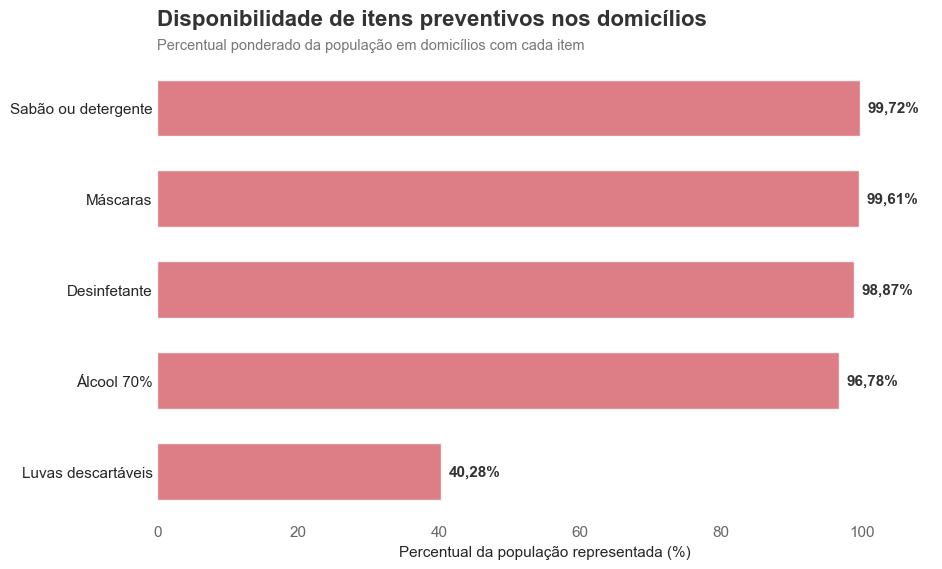

In [86]:
sns.set_theme(
    style="white",
    context="notebook"
)

df_grafico_comportamento = (
    df_itens_prevencao
    .sort_values(
        "percentual_ponderado",
        ascending=True
    )
    .copy()
)

cor_barra = "#D96C75"
cor_texto = "#333333"

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="white"
)

barras = ax.barh(
    df_grafico_comportamento["nome_item"],
    df_grafico_comportamento["percentual_ponderado"],
    color=cor_barra,
    alpha=0.88,
    height=0.62
)

for barra, percentual in zip(
    barras,
    df_grafico_comportamento["percentual_ponderado"]
):
    ax.text(
        percentual + 1,
        barra.get_y() + barra.get_height() / 2,
        f"{percentual:.2f}%".replace(".", ","),
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color=cor_texto
    )

ax.set_title(
    "Disponibilidade de itens preventivos nos domicílios",
    fontsize=16,
    fontweight="bold",
    color=cor_texto,
    loc="left",
    pad=24
)

ax.text(
    0,
    1.02,
    "Percentual ponderado da população em domicílios com cada item",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel(
    "Percentual da população representada (%)",
    fontsize=11
)

ax.set_ylabel("")
ax.set_xlim(0, 110)
ax.grid(False)

for borda in [
    "top",
    "right",
    "left",
    "bottom"
]:
    ax.spines[borda].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
    labelsize=11
)

ax.tick_params(
    axis="x",
    length=0,
    colors="#666666"
)

fig.savefig(
    PASTA_IMAGENS / "itens_prevencao.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

**Resultado complementar.** Sabão ou detergente (**99,72%**), máscaras (**99,61%**), desinfetante (**98,87%**) e álcool 70% (**96,78%**) apresentaram ampla disponibilidade domiciliar. Luvas descartáveis foram menos frequentes (**40,28%**).

> As colunas de estimativa ponderada somam pesos das três rodadas mensais e, portanto, representam pessoas-mês. Para comunicar o comportamento do período, devem ser priorizados os percentuais.

## 6. Modelo de clusterização

### 6.1 Objetivo

A clusterização foi aplicada somente aos registros que declararam pelo menos um teste positivo. O objetivo foi encontrar grupos com características demográficas, clínicas e comportamentais semelhantes.

O método escolhido foi o `MiniBatchKMeans`, uma versão do K-Means adequada ao volume da base. Como a clusterização é um aprendizado não supervisionado, não existe uma variável-alvo a ser prevista.

In [46]:
sql_base_clusterizacao = text("""
    SELECT
        id_registro, mes_referencia, peso_amostral,
        idade, sexo, cor_raca, escolaridade, uf, situacao_domicilio,
        sintoma_febre, sintoma_tosse, sintoma_dor_garganta,
        sintoma_dificuldade_respirar, sintoma_dor_cabeca, sintoma_dor_peito,
        sintoma_nausea, sintoma_nariz_entupido, sintoma_fadiga,
        sintoma_dor_olhos, sintoma_perda_olfato_paladar,
        sintoma_dor_muscular, sintoma_diarreia,
        possui_diabetes, possui_hipertensao, possui_doenca_respiratoria,
        possui_doenca_coracao, possui_depressao, possui_cancer,
        nivel_restricao_contato,
        trabalhou_na_semana, afastado_do_trabalho,
        trabalhou_local_habitual, trabalho_remoto,
        domicilio_possui_sabao, domicilio_possui_alcool_70,
        domicilio_possui_mascaras, domicilio_possui_luvas,
        domicilio_possui_desinfetante
    FROM public.pnad_covid
    WHERE infectado = 1
    ORDER BY id_registro;
""")

df_infectados_cluster = pd.read_sql(sql_base_clusterizacao, engine)

print(f"Registros extraídos: {len(df_infectados_cluster):,}")
print(f"Quantidade de colunas: {df_infectados_cluster.shape[1]}")
df_infectados_cluster.head()

Registros extraídos: 32,922
Quantidade de colunas: 38


,id_registro,mes_referencia,peso_amostral,idade,sexo,cor_raca,escolaridade,uf,situacao_domicilio,sintoma_febre,...,nivel_restricao_contato,trabalhou_na_semana,afastado_do_trabalho,trabalhou_local_habitual,trabalho_remoto,domicilio_possui_sabao,domicilio_possui_alcool_70,domicilio_possui_mascaras,domicilio_possui_luvas,domicilio_possui_desinfetante
0,24,2020-09,166.944610,36,2,4,7,11,1,2,...,2,2,2,None,None,1,1,1,1,1
1,31,2020-09,127.536682,50,2,4,2,11,1,2,...,3,1,None,1,None,1,1,1,2,1
2,32,2020-09,164.398293,45,1,4,2,11,1,2,...,2,1,None,1,None,1,1,1,2,1
3,52,2020-09,938.068587,32,2,4,4,11,1,2,...,2,1,None,1,None,1,1,1,2,1
4,53,2020-09,974.218269,28,1,4,4,11,1,2,...,2,1,None,1,None,1,1,1,2,1


In [47]:
colunas_sintomas = [
    "sintoma_febre",
    "sintoma_tosse",
    "sintoma_dor_garganta",
    "sintoma_dificuldade_respirar",
    "sintoma_dor_cabeca",
    "sintoma_dor_peito",
    "sintoma_nausea",
    "sintoma_nariz_entupido",
    "sintoma_fadiga",
    "sintoma_dor_olhos",
    "sintoma_perda_olfato_paladar",
    "sintoma_dor_muscular",
    "sintoma_diarreia"
]

colunas_comorbidades = [
    "possui_diabetes",
    "possui_hipertensao",
    "possui_doenca_respiratoria",
    "possui_doenca_coracao",
    "possui_depressao",
    "possui_cancer"
]

colunas_prevencao = [
    "domicilio_possui_sabao",
    "domicilio_possui_alcool_70",
    "domicilio_possui_mascaras",
    "domicilio_possui_luvas",
    "domicilio_possui_desinfetante"
]

In [48]:
base_modelo = df_infectados_cluster.copy()
base_modelo["quantidade_sintomas"] = base_modelo[colunas_sintomas].eq("1").sum(axis=1)
base_modelo["quantidade_comorbidades"] = base_modelo[colunas_comorbidades].eq("1").sum(axis=1)
base_modelo["quantidade_itens_prevencao"] = base_modelo[colunas_prevencao].eq("1").sum(axis=1)

In [49]:
def classificar_modalidade_trabalho(linha):
    if linha["trabalhou_na_semana"] == "1":

        if (
            linha["trabalhou_local_habitual"] == "2"
            and linha["trabalho_remoto"] == "1"
        ):
            return "Remoto"

        if (
            linha["trabalhou_local_habitual"] == "1"
            or (
                linha["trabalhou_local_habitual"] == "2"
                and linha["trabalho_remoto"] == "2"
            )
        ):
            return "Presencial"

        return "Trabalhou - modalidade não informada"

    if (
        linha["trabalhou_na_semana"] == "2"
        and linha["afastado_do_trabalho"] == "1"
    ):
        return "Afastado"

    if linha["trabalhou_na_semana"] == "2":
        return "Não trabalhou"

    return "Não informado"


base_modelo["modalidade_trabalho"] = (
    base_modelo.apply(
        classificar_modalidade_trabalho,
        axis=1
    )
)

In [50]:
mapa_regiao = {
    "11": "Norte",
    "12": "Norte",
    "13": "Norte",
    "14": "Norte",
    "15": "Norte",
    "16": "Norte",
    "17": "Norte",

    "21": "Nordeste",
    "22": "Nordeste",
    "23": "Nordeste",
    "24": "Nordeste",
    "25": "Nordeste",
    "26": "Nordeste",
    "27": "Nordeste",
    "28": "Nordeste",
    "29": "Nordeste",

    "31": "Sudeste",
    "32": "Sudeste",
    "33": "Sudeste",
    "35": "Sudeste",

    "41": "Sul",
    "42": "Sul",
    "43": "Sul",

    "50": "Centro-Oeste",
    "51": "Centro-Oeste",
    "52": "Centro-Oeste",
    "53": "Centro-Oeste"
}

base_modelo["regiao"] = (
    base_modelo["uf"]
    .astype("string")
    .map(mapa_regiao)
    .fillna("Não informada")
)

In [51]:
variaveis_numericas_modelo = [
    "idade",
    "quantidade_sintomas",
    "quantidade_comorbidades",
    "quantidade_itens_prevencao",
    "nivel_restricao_contato"
]

variaveis_categoricas_modelo = [
    "sexo",
    "cor_raca",
    "escolaridade",
    "situacao_domicilio",
    "regiao",
    "modalidade_trabalho"
]

variaveis_modelo = (
    variaveis_numericas_modelo
    + variaveis_categoricas_modelo
)

In [52]:
# O código 9 representa resposta ignorada, por isso foi tratado como nulo.
base_modelo["nivel_restricao_contato"] = (
    pd.to_numeric(base_modelo["nivel_restricao_contato"], errors="coerce")
    .replace(9, np.nan)
)

In [53]:
mapa_sexo = {
    "1": "Homem",
    "2": "Mulher",
    "9": "Ignorado"
}

mapa_situacao_domicilio = {
    "1": "Urbano",
    "2": "Rural"
}

base_modelo["sexo"] = (
    base_modelo["sexo"]
    .astype("string")
    .map(mapa_sexo)
    .fillna("Não informado")
)

base_modelo["situacao_domicilio"] = (
    base_modelo["situacao_domicilio"]
    .astype("string")
    .map(mapa_situacao_domicilio)
    .fillna("Não informado")
)

In [54]:
dados_modelo = (
    base_modelo[variaveis_modelo]
    .copy()
)

for coluna in variaveis_numericas_modelo:
    dados_modelo[coluna] = pd.to_numeric(
        dados_modelo[coluna],
        errors="coerce"
    )

for coluna in variaveis_categoricas_modelo:
    dados_modelo[coluna] = (
        dados_modelo[coluna]
        .astype("string")
        .fillna("Não informado")
    )

In [55]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [56]:
pipeline_numerico = Pipeline([
    ("preencher_nulos", SimpleImputer(strategy="median")),
    ("padronizar", StandardScaler()),
])

pipeline_categorico = Pipeline([
    ("preencher_nulos", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessador = ColumnTransformer([
    ("numericas", pipeline_numerico, variaveis_numericas_modelo),
    ("categoricas", pipeline_categorico, variaveis_categoricas_modelo),
])

In [57]:
matriz_modelo = (
    preprocessador
    .fit_transform(dados_modelo)
)

print(
    f"Dimensão após a transformação: "
    f"{matriz_modelo.shape}"
)

print(
    f"Existem valores inválidos? "
    f"{not np.isfinite(matriz_modelo).all()}"
)

Dimensão após a transformação: (32922, 34)
Existem valores inválidos? False


In [58]:
resultados_k = []

for quantidade_clusters in range(2, 9):

    modelo_teste = MiniBatchKMeans(
        n_clusters=quantidade_clusters,
        random_state=42,
        n_init=20,
        batch_size=2048
    )

    rotulos_teste = (
        modelo_teste
        .fit_predict(matriz_modelo)
    )

    silhouette = silhouette_score(
        matriz_modelo,
        rotulos_teste,
        sample_size=10_000,
        random_state=42
    )

    resultados_k.append({
        "quantidade_clusters": quantidade_clusters,
        "inercia": modelo_teste.inertia_,
        "silhouette_score": silhouette
    })

    print(
        f"K = {quantidade_clusters} | "
        f"Inércia = {modelo_teste.inertia_:,.2f} | "
        f"Silhouette = {silhouette:.4f}"
    )

K = 2 | Inércia = 249,099.14 | Silhouette = 0.1371
K = 3 | Inércia = 223,707.80 | Silhouette = 0.1388
K = 4 | Inércia = 207,109.28 | Silhouette = 0.1051
K = 5 | Inércia = 185,460.34 | Silhouette = 0.1232
K = 6 | Inércia = 181,395.13 | Silhouette = 0.1004
K = 7 | Inércia = 176,092.26 | Silhouette = 0.0923
K = 8 | Inércia = 170,919.09 | Silhouette = 0.0931


In [59]:
df_avaliacao_clusters = pd.DataFrame(
    resultados_k
)

df_avaliacao_clusters

,quantidade_clusters,inercia,silhouette_score
0,2,249099.139331,0.137095
1,3,223707.800113,0.138772
2,4,207109.281561,0.105084
3,5,185460.336624,0.123152
4,6,181395.134385,0.100386
5,7,176092.263515,0.092330
6,8,170919.093120,0.093063


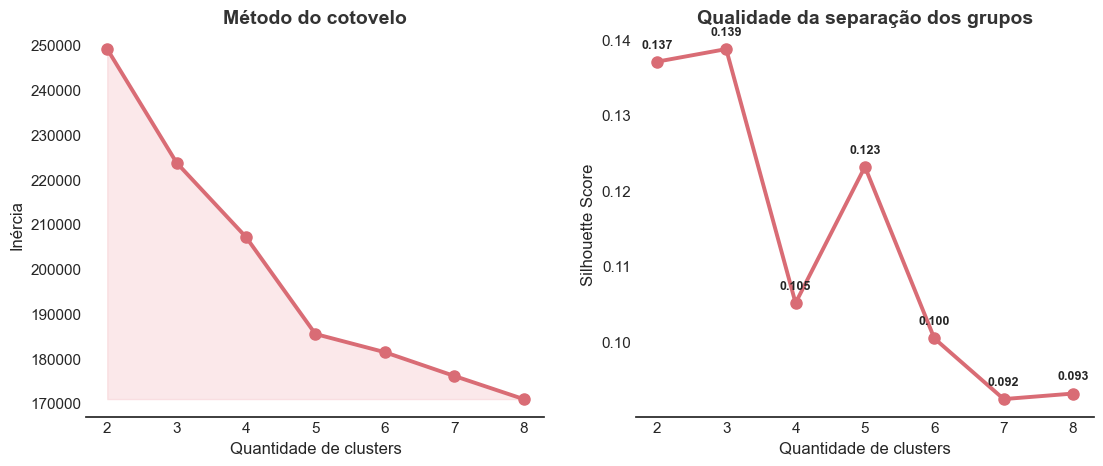

In [87]:
fig, eixos = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    facecolor="white"
)

cor_principal = "#D96C75"
cor_area = "#F3B5BA"
cor_texto = "#333333"

# Método do cotovelo
eixos[0].plot(
    df_avaliacao_clusters["quantidade_clusters"],
    df_avaliacao_clusters["inercia"],
    color=cor_principal,
    linewidth=2.8,
    marker="o",
    markersize=8
)

eixos[0].fill_between(
    df_avaliacao_clusters["quantidade_clusters"],
    df_avaliacao_clusters["inercia"],
    df_avaliacao_clusters["inercia"].min(),
    color=cor_area,
    alpha=0.30
)

eixos[0].set_title(
    "Método do cotovelo",
    fontsize=14,
    fontweight="bold",
    color=cor_texto
)

eixos[0].set_xlabel(
    "Quantidade de clusters"
)

eixos[0].set_ylabel(
    "Inércia"
)

# Silhouette Score
eixos[1].plot(
    df_avaliacao_clusters["quantidade_clusters"],
    df_avaliacao_clusters["silhouette_score"],
    color=cor_principal,
    linewidth=2.8,
    marker="o",
    markersize=8
)

for _, linha in df_avaliacao_clusters.iterrows():
    eixos[1].annotate(
        f"{linha['silhouette_score']:.3f}",
        xy=(
            linha["quantidade_clusters"],
            linha["silhouette_score"]
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

eixos[1].set_title(
    "Qualidade da separação dos grupos",
    fontsize=14,
    fontweight="bold",
    color=cor_texto
)

eixos[1].set_xlabel(
    "Quantidade de clusters"
)

eixos[1].set_ylabel(
    "Silhouette Score"
)

for eixo in eixos:
    eixo.grid(False)

    eixo.spines["top"].set_visible(False)
    eixo.spines["right"].set_visible(False)
    eixo.spines["left"].set_visible(False)

    eixo.tick_params(
        axis="both",
        length=0
    )

fig.savefig(
    PASTA_IMAGENS / "avaliacao_clusters.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

### 6.2 Escolha da quantidade de clusters

Foram testadas soluções de 2 a 8 clusters. O modelo com 3 grupos apresentou o maior `Silhouette Score` após o tratamento do código ignorado da variável de restrição. A solução com 5 grupos também foi avaliada por causa do ponto de estabilização da inércia, mas gerou dois grupos muito parecidos. Por isso, a solução final foi definida com **3 clusters**.

O `Silhouette Score` final foi de aproximadamente **0,139**. O valor mostra que existe sobreposição entre os grupos, algo esperado em dados sociais e comportamentais.

In [61]:
quantidade_clusters_final = 3

modelo_clusterizacao_final = MiniBatchKMeans(
    n_clusters=quantidade_clusters_final,
    random_state=42,
    n_init=30,
    batch_size=2048,
)

base_modelo["cluster_final"] = modelo_clusterizacao_final.fit_predict(matriz_modelo)

print("Modelo final treinado com 3 clusters.")
print(base_modelo["cluster_final"].value_counts().sort_index())

Modelo final treinado com 3 clusters.
cluster_final
0    17418
1     6470
2     9034
Name: count, dtype: int64


### 6.3 Caracterização dos grupos

In [62]:
resumo_clusters = (
    base_modelo.groupby("cluster_final")
    .agg(
        registros=("id_registro", "count"),
        idade_media=("idade", "mean"),
        sintomas_medios=("quantidade_sintomas", "mean"),
        comorbidades_medias=("quantidade_comorbidades", "mean"),
        itens_prevencao_medios=("quantidade_itens_prevencao", "mean"),
        restricao_media=("nivel_restricao_contato", "mean"),
    )
    .reset_index()
)

resumo_clusters["percentual_amostra"] = (
    100 * resumo_clusters["registros"] / resumo_clusters["registros"].sum()
)

resumo_clusters.round(2)

,cluster_final,registros,idade_media,sintomas_medios,comorbidades_medias,itens_prevencao_medios,restricao_media,percentual_amostra
0,0,17418,38.71,0.12,0.18,4.44,1.91,52.91
1,1,6470,61.91,0.67,1.50,4.40,2.89,19.65
2,2,9034,29.91,1.30,0.10,4.36,3.21,27.44


In [63]:
sintomas_por_cluster = base_modelo[colunas_sintomas].eq("1").astype("int8")
sintomas_por_cluster["cluster_final"] = base_modelo["cluster_final"].to_numpy()

perfil_sintomas = (
    sintomas_por_cluster.groupby("cluster_final").mean().mul(100).round(2)
)

perfil_sintomas.T

cluster_final,0,1,2
sintoma_febre,1.27,5.69,12.80
sintoma_tosse,1.44,7.33,12.71
sintoma_dor_garganta,1.25,5.12,11.38
sintoma_dificuldade_respirar,0.58,4.48,7.35
sintoma_dor_cabeca,1.95,7.79,15.03
sintoma_dor_peito,0.33,3.09,6.24
sintoma_nausea,0.30,3.12,6.62
sintoma_nariz_entupido,1.08,4.88,10.43
sintoma_fadiga,0.97,7.11,11.11
sintoma_dor_olhos,0.33,2.87,6.14


In [64]:
comorbidades_por_cluster = base_modelo[colunas_comorbidades].eq("1").astype("int8")
comorbidades_por_cluster["cluster_final"] = base_modelo["cluster_final"].to_numpy()

perfil_comorbidades = (
    comorbidades_por_cluster.groupby("cluster_final").mean().mul(100).round(2)
)

perfil_comorbidades.T

cluster_final,0,1,2
possui_diabetes,2.20,33.62,0.74
possui_hipertensao,8.04,68.86,2.65
possui_doenca_respiratoria,4.70,13.28,4.54
possui_doenca_coracao,0.83,15.07,0.46
possui_depressao,2.04,13.76,1.75
possui_cancer,0.39,5.41,0.19


### 6.4 Nomeação dos perfis

- **Cluster 0 — Adultos com poucos sintomas:** idade média de 38,71 anos e baixa presença de sintomas na semana da entrevista.
- **Cluster 1 — Mais velhos com comorbidades:** idade média de 61,91 anos e maior presença de condições preexistentes.
- **Cluster 2 — Jovens com mais sintomas:** idade média de 29,91 anos e maior média de sintomas entre os grupos. Isso não significa maior gravidade da doença.

In [65]:
nomes_clusters = {
    0: "Adultos com poucos sintomas",
    1: "Mais velhos com comorbidades",
    2: "Jovens com mais sintomas",
}

base_modelo["perfil_cluster"] = base_modelo["cluster_final"].map(nomes_clusters)

In [66]:
distribuicao_final_clusters = (
    base_modelo
    .groupby(
        [
            "cluster_final",
            "perfil_cluster"
        ]
    )
    .agg(
        registros=(
            "id_registro",
            "count"
        )
    )
    .reset_index()
)

distribuicao_final_clusters[
    "percentual"
] = (
    100
    * distribuicao_final_clusters["registros"]
    / distribuicao_final_clusters["registros"].sum()
).round(2)

distribuicao_final_clusters

,cluster_final,perfil_cluster,registros,percentual
0,0,Adultos com poucos sintomas,17418,52.91
1,1,Mais velhos com comorbidades,6470,19.65
2,2,Jovens com mais sintomas,9034,27.44


### 6.5 Distribuição dos perfis

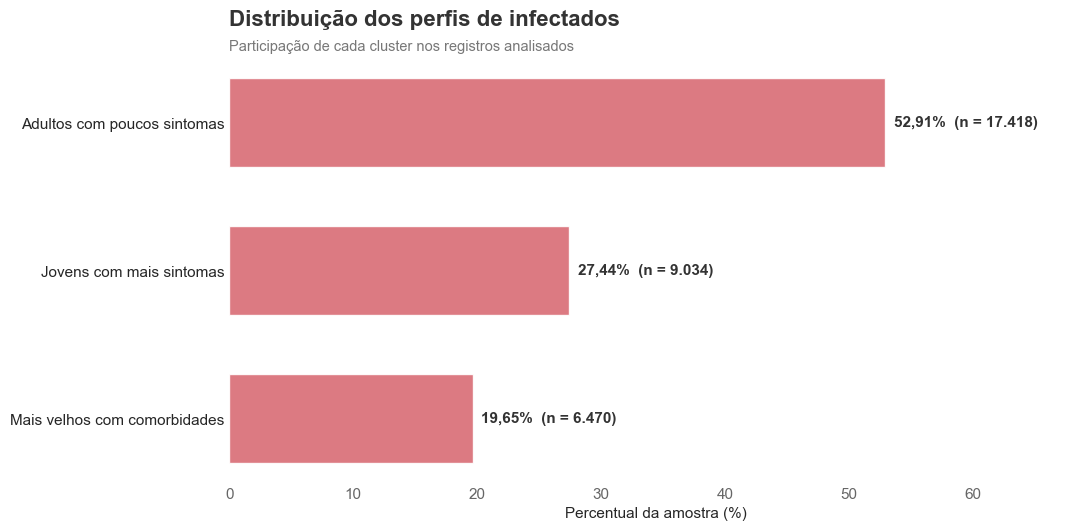

In [88]:
df_grafico_clusters = (
    distribuicao_final_clusters
    .sort_values(
        "percentual",
        ascending=True
    )
    .copy()
)

cor_barra = "#D96C75"
cor_texto = "#333333"

fig, ax = plt.subplots(
    figsize=(11, 5.5),
    facecolor="white"
)

barras = ax.barh(
    df_grafico_clusters["perfil_cluster"],
    df_grafico_clusters["percentual"],
    color=cor_barra,
    alpha=0.90,
    height=0.60
)

for barra, (_, linha) in zip(
    barras,
    df_grafico_clusters.iterrows()
):
    percentual_formatado = (
        f"{linha['percentual']:.2f}%"
        .replace(".", ",")
    )

    registros_formatados = (
        f"{int(linha['registros']):,}"
        .replace(",", ".")
    )

    ax.text(
        barra.get_width() + 0.7,
        barra.get_y() + barra.get_height() / 2,
        (
            f"{percentual_formatado}  "
            f"(n = {registros_formatados})"
        ),
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color=cor_texto
    )

ax.set_title(
    "Distribuição dos perfis de infectados",
    fontsize=16,
    fontweight="bold",
    color=cor_texto,
    loc="left",
    pad=24
)

ax.text(
    0,
    1.02,
    "Participação de cada cluster nos registros analisados",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel(
    "Percentual da amostra (%)",
    fontsize=11
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    df_grafico_clusters["percentual"].max() * 1.30
)

ax.grid(False)

for borda in [
    "top",
    "right",
    "left",
    "bottom"
]:
    ax.spines[borda].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
    labelsize=11
)

ax.tick_params(
    axis="x",
    length=0,
    colors="#666666"
)

fig.savefig(
    PASTA_IMAGENS / "distribuicao_clusters.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

### 6.6 Comparação das características

In [68]:
perfil_heatmap = (
    base_modelo
    .groupby("perfil_cluster")
    .agg(
        idade_media=(
            "idade",
            "mean"
        ),

        sintomas_medios=(
            "quantidade_sintomas",
            "mean"
        ),

        comorbidades_medias=(
            "quantidade_comorbidades",
            "mean"
        ),

        itens_prevencao_medios=(
            "quantidade_itens_prevencao",
            "mean"
        ),

        restricao_media=(
            "nivel_restricao_contato",
            "mean"
        )
    )
    .reindex(
        [
            "Adultos com poucos sintomas",
            "Mais velhos com comorbidades",
            "Jovens com mais sintomas"
        ]
    )
    .round(2)
)

perfil_heatmap

,idade_media,sintomas_medios,comorbidades_medias,itens_prevencao_medios,restricao_media
perfil_cluster,,,,,
Adultos com poucos sintomas,38.71,0.12,0.18,4.44,1.91
Mais velhos com comorbidades,61.91,0.67,1.50,4.40,2.89
Jovens com mais sintomas,29.91,1.30,0.10,4.36,3.21


In [69]:
perfil_heatmap_normalizado = (
    perfil_heatmap
    .copy()
)

# Idade observada entre 0 e 102 anos
perfil_heatmap_normalizado[
    "idade_media"
] = (
    perfil_heatmap["idade_media"]
    / base_modelo["idade"].max()
)

# Quantidade possível: 0 a 13 sintomas
perfil_heatmap_normalizado[
    "sintomas_medios"
] = (
    perfil_heatmap["sintomas_medios"]
    / len(colunas_sintomas)
)

# Quantidade possível: 0 a 6 comorbidades
perfil_heatmap_normalizado[
    "comorbidades_medias"
] = (
    perfil_heatmap["comorbidades_medias"]
    / len(colunas_comorbidades)
)

# Quantidade possível: 0 a 5 itens
perfil_heatmap_normalizado[
    "itens_prevencao_medios"
] = (
    perfil_heatmap["itens_prevencao_medios"]
    / len(colunas_prevencao)
)

# Nível de restrição entre 1 e 4
perfil_heatmap_normalizado[
    "restricao_media"
] = (
    (
        perfil_heatmap["restricao_media"]
        - 1
    )
    / 3
)

perfil_heatmap_normalizado = (
    perfil_heatmap_normalizado
    .clip(0, 1)
)

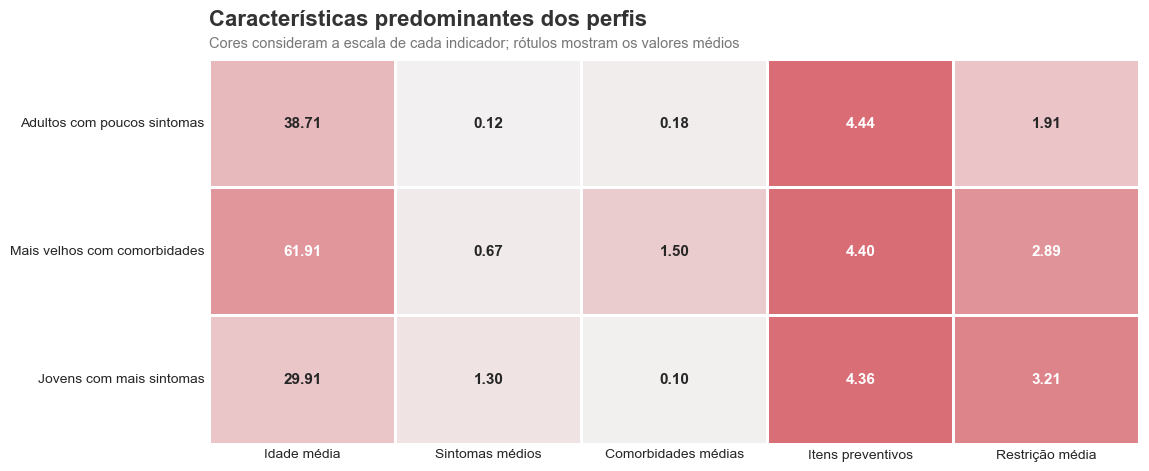

In [89]:
nomes_colunas_heatmap = {
    "idade_media": "Idade média",
    "sintomas_medios": "Sintomas médios",
    "comorbidades_medias": "Comorbidades médias",
    "itens_prevencao_medios": "Itens preventivos",
    "restricao_media": "Restrição média"
}

dados_cores = (
    perfil_heatmap_normalizado
    .rename(columns=nomes_colunas_heatmap)
)

dados_rotulos = (
    perfil_heatmap
    .rename(columns=nomes_colunas_heatmap)
)

mapa_vermelho_pastel = sns.light_palette(
    "#D96C75",
    as_cmap=True
)

fig, ax = plt.subplots(
    figsize=(12, 5),
    facecolor="white"
)

sns.heatmap(
    dados_cores,
    annot=dados_rotulos,
    fmt=".2f",
    cmap=mapa_vermelho_pastel,
    linewidths=2,
    linecolor="white",
    cbar=False,
    annot_kws={
        "fontsize": 11,
        "fontweight": "bold"
    },
    ax=ax
)

ax.set_title(
    "Características predominantes dos perfis",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.03,
    "Cores consideram a escala de cada indicador; rótulos mostram os valores médios",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=10
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

ax.tick_params(
    axis="both",
    length=0
)

fig.savefig(
    PASTA_IMAGENS / "caracteristicas_clusters.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

### 6.7 Visualização dos clusters com PCA

O PCA reduziu as variáveis transformadas para duas dimensões. Essa projeção facilita a visualização dos grupos, mas não substitui todas as informações usadas pelo modelo.

In [71]:
pca = PCA(n_components=2, random_state=42)
componentes_pca = pca.fit_transform(matriz_modelo)
variancia_pca = pca.explained_variance_ratio_ * 100

print(f"Componente 1: {variancia_pca[0]:.2f}%")
print(f"Componente 2: {variancia_pca[1]:.2f}%")
print(f"Variância total representada: {variancia_pca.sum():.2f}%")

Componente 1: 18.42%
Componente 2: 14.31%
Variância total representada: 32.74%


In [72]:
df_pca = pd.DataFrame({
    "componente_1": componentes_pca[:, 0],
    "componente_2": componentes_pca[:, 1],

    "cluster_final": (
        base_modelo["cluster_final"]
        .to_numpy()
    ),

    "perfil_cluster": (
        base_modelo["perfil_cluster"]
        .to_numpy()
    )
})

df_pca.head()

,componente_1,componente_2,cluster_final,perfil_cluster
0,-0.645396,-0.176879,0,Adultos com poucos sintomas
1,0.904111,-0.218889,1,Mais velhos com comorbidades
2,-0.743004,-0.442959,0,Adultos com poucos sintomas
3,-1.112015,-0.053954,0,Adultos com poucos sintomas
4,-1.351095,-0.010650,0,Adultos com poucos sintomas


In [73]:
df_pca_grafico = df_pca.sample(
    n=min(10_000, len(df_pca)),
    random_state=42,
).copy()

In [74]:
cores_clusters = {
    "Adultos com poucos sintomas": "#D96C75",
    "Mais velhos com comorbidades": "#7A5C61",
    "Jovens com mais sintomas": "#E9B1B6"
}

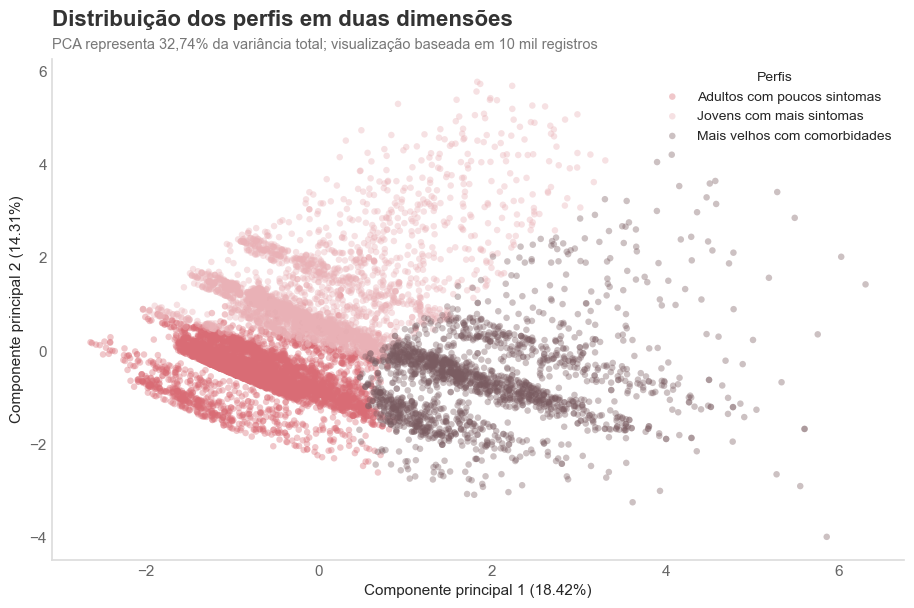

In [90]:
fig, ax = plt.subplots(
    figsize=(11, 6.5),
    facecolor="white"
)

for perfil, dados_perfil in (
    df_pca_grafico
    .groupby("perfil_cluster")
):
    ax.scatter(
        dados_perfil["componente_1"],
        dados_perfil["componente_2"],
        label=perfil,
        color=cores_clusters[perfil],
        s=22,
        alpha=0.38,
        edgecolors="none"
    )

ax.set_title(
    "Distribuição dos perfis em duas dimensões",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.02,
    (
        "PCA representa 32,74% da variância total; "
        "visualização baseada em 10 mil registros"
    ),
    transform=ax.transAxes,
    fontsize=10.5,
    color="#777777",
    ha="left"
)

ax.set_xlabel(
    (
        "Componente principal 1 "
        f"({variancia_pca[0]:.2f}%)"
    ),
    fontsize=11
)

ax.set_ylabel(
    (
        "Componente principal 2 "
        f"({variancia_pca[1]:.2f}%)"
    ),
    fontsize=11
)

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(
    "#DDDDDD"
)

ax.spines["bottom"].set_color(
    "#DDDDDD"
)

ax.tick_params(
    axis="both",
    length=0,
    colors="#666666"
)

ax.legend(
    title="Perfis",
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    loc="best"
)

fig.savefig(
    PASTA_IMAGENS / "clusters_pca.png",
    dpi=160,
    bbox_inches="tight",
    facecolor="white"
)

A projeção PCA mostra uma tendência de separação entre os perfis, mas ainda existe sobreposição. O grupo mais velho e com maior presença de comorbidades aparece principalmente à direita do gráfico. Os jovens com mais sintomas ficam mais dispersos na parte superior, enquanto os adultos com poucos sintomas se concentram na região central e inferior esquerda.

As duas componentes representam **32,74%** da variância total. Portanto, o gráfico mostra apenas uma visão simplificada do modelo. A sobreposição é compatível com o `Silhouette Score` de aproximadamente **0,139**.

### 6.8 Resultado da clusterização

O modelo identificou três perfis entre os registros com teste positivo:

- **Adultos com poucos sintomas:** 52,91% da amostra, idade média de 38,71 anos e baixa presença de sintomas na semana de referência.
- **Mais velhos com comorbidades:** 19,65% dos registros, idade média de 61,91 anos e maior presença de hipertensão, diabetes e outras condições preexistentes.
- **Jovens com mais sintomas:** 27,44% da amostra, idade média de 29,91 anos, poucas comorbidades e maior presença de sintomas entre os grupos.

Os resultados são descritivos. Eles não representam diagnóstico, prognóstico ou relação causal. Além disso, os sintomas se referem à semana da entrevista, enquanto o teste positivo pode ter ocorrido anteriormente.

### 6.9 Salvamento e validação do modelo

In [76]:
arquivo_modelo = (
    PASTA_MODELO
    / "modelo_clusterizacao_pnad_covid.joblib"
)

print("Arquivo do modelo:", arquivo_modelo)

Arquivo do modelo: c:\Users\LUIS\OneDrive\MEU ARQUIVOS - CURSOS\FACULDADE\FIAP\FASE 3\pnad_covid_fase3\modelo\modelo_clusterizacao_pnad_covid.joblib


In [77]:
pacote_modelo = {
    "modelo": modelo_clusterizacao_final,
    "preprocessador": preprocessador,
    "quantidade_clusters": quantidade_clusters_final,
    "nomes_clusters": nomes_clusters,
    "variaveis_numericas": variaveis_numericas_modelo,
    "variaveis_categoricas": variaveis_categoricas_modelo,
    "silhouette_score": 0.138772,
    "variancia_pca_duas_dimensoes": float(variancia_pca.sum()),
    "versao_sklearn": sklearn.__version__,
}

In [78]:
joblib.dump(pacote_modelo, arquivo_modelo, compress=3)
tamanho_modelo_mb = arquivo_modelo.stat().st_size / 1024**2

print("Modelo salvo com sucesso!")
print(f"Tamanho do arquivo: {tamanho_modelo_mb:.2f} MB")

Modelo salvo com sucesso!
Tamanho do arquivo: 0.02 MB


In [79]:
pacote_carregado = joblib.load(arquivo_modelo)
preprocessador_carregado = pacote_carregado["preprocessador"]
modelo_carregado = pacote_carregado["modelo"]

In [80]:
amostra_validacao = dados_modelo.head(100).copy()
matriz_validacao = preprocessador_carregado.transform(amostra_validacao)

clusters_recalculados = modelo_carregado.predict(matriz_validacao)
clusters_originais = base_modelo["cluster_final"].head(100).to_numpy()

In [81]:
validacao_modelo = np.array_equal(clusters_recalculados, clusters_originais)
print("O modelo carregado reproduziu os mesmos resultados?", validacao_modelo)

O modelo carregado reproduziu os mesmos resultados? True


O arquivo `.joblib` foi carregado e aplicado novamente a uma amostra de 100 registros. Como os clusters foram reproduzidos integralmente, o salvamento do pré-processador e do modelo foi validado.

## 7. Conclusão

Entre setembro e novembro de 2020, aumentou a proporção ponderada de entrevistados que declararam teste positivo. O maior percentual ocorreu entre mulheres de 30 a 39 anos. As taxas de positivos ficaram praticamente iguais entre trabalho presencial e remoto, enquanto os indicadores comportamentais mostraram ampla adoção de restrições de contato e grande disponibilidade de itens preventivos nos domicílios.

A clusterização complementou a análise ao separar os registros positivos em três perfis de fácil interpretação. Mesmo com sobreposição entre os grupos, o modelo ajudou a distinguir pessoas com baixa presença de sintomas, pessoas mais velhas com comorbidades e jovens com maior presença de sintomas.

As conclusões devem ser interpretadas dentro das limitações da PNAD COVID-19 e do caráter descritivo deste trabalho.